In [55]:
import pandas as pd

In [56]:
remote_kw = pd.read_parquet('../data/remote_kw_labels_2024.parquet.gzip')

In [4]:
remote_kw

,ID,REMOTE_KW
0,b88e3e5a44a4f2fefc0d0b730e1ff8d7198860e1,False
1,288b9b6066d4ffedcd64ab53faeaef8ec3134eaa,False
2,44951c6c9e444a134eb6c65ba86023814eb2821e,False
3,d7faeb084f0cbe87df532a0aa915e842a6d32460,False
4,2429b0af818e24fb5bb97288a050ccedabc097ad,False
...,...,...
11729657,a3235d85aa186fc0d699c398949aaeb7509d5ef4,False
11729658,24becaa8883e985649781959c7bdb8a953773fa4,False
11729659,dd39b807448e4dfea88bb044c2fcc3dac0abf320,False
11729660,cf9932afd14a3b13ced8885fd9eba19cc7e57b26,False


In [6]:
remote_kw['REMOTE_KW'].value_counts()

REMOTE_KW
False    11048634
True       681028
Name: count, dtype: int64

In [57]:
df = pd.read_parquet('../data/us_10m_nointernship_2018_2024_benefits.parquet.gzip')

In [58]:
len(df)

9872916

In [44]:
# og_df = pd.read_parquet('../data/us_10m_nointernship_ai_skills_benefits.parquet.gzip')

In [45]:
len(og_df)

11581326

In [59]:
df.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'SALARY', 'EXPIRED', 'DURATION',
       'AI ROLE', 'wfh_wham_prob', 'wfh_wham', 'YEAR', 'EDU_ASSISTANCE',
       'PAID LEAVE', 'WELLBEING', 'HEALTH_WELLBEING', 'PARENTAL_LEAVE',
       'CULTURE'],
      dtype='object')

In [60]:
df = df.merge(remote_kw, on='ID', how = 'left')

In [62]:
len(df)

9872916

In [63]:
df['REMOTE_KW'].value_counts(dropna=False)

REMOTE_KW
False    9286358
True      586558
Name: count, dtype: int64

In [26]:
# 2023 
df['REMOTE_KW'].value_counts(dropna=False)

REMOTE_KW
False    10916201
True       665125
Name: count, dtype: int64

In [64]:
df['wfh_wham'].value_counts(dropna=False)

wfh_wham
NaN    9466179
0.0     373731
1.0      33006
Name: count, dtype: int64

# 2023 Metrics

In [31]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
wham_df = df[df['wfh_wham'].notnull()]

In [40]:
len(wham_df)

9826890

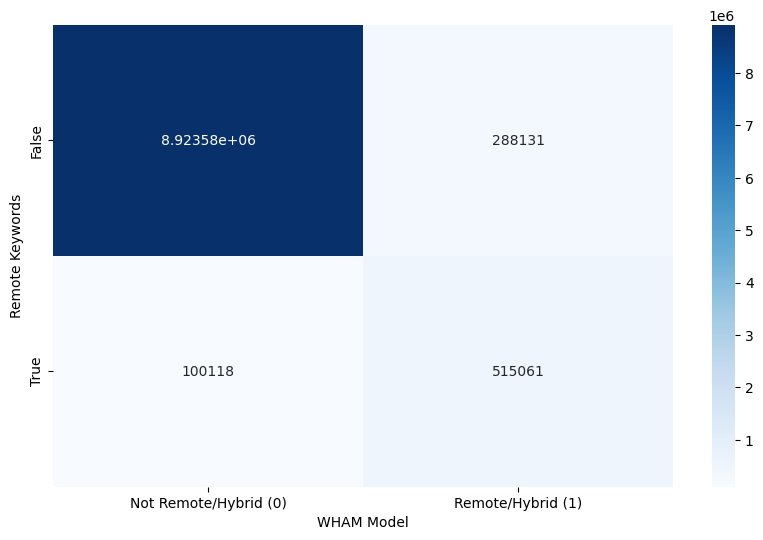

In [41]:


# Pivot the data to create a confusion matrix format
# cf_df = usdf[usdf['REMOTE_TYPE_NAME']!='[None]']
confusion_matrix = wham_df.groupby(['REMOTE_KW', 'wfh_wham']).size().unstack().fillna(0)
confusion_matrix.columns = ['Not Remote/Hybrid (0)', 'Remote/Hybrid (1)']
confusion_matrix.index.name = 'Remote_KW'

# Plot the confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues')
plt.ylabel('Remote Keywords')
plt.xlabel('WHAM Model')
plt.show()


In [42]:
# Calculate metrics
y_true = wham_df['REMOTE_KW']
y_pred = wham_df['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.96
Precision: 0.64
Recall: 0.84
F1 Score: 0.73


In [ ]:
# Calculate metrics
y_true = wham_df['REMOTE_KW']
y_pred = wham_df['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.96
Precision: 0.64
Recall: 0.84
F1 Score: 0.73


# 2024 Metrics

In [65]:
wham_df = df[df['wfh_wham'].notnull()]

In [66]:
len(wham_df)

406737

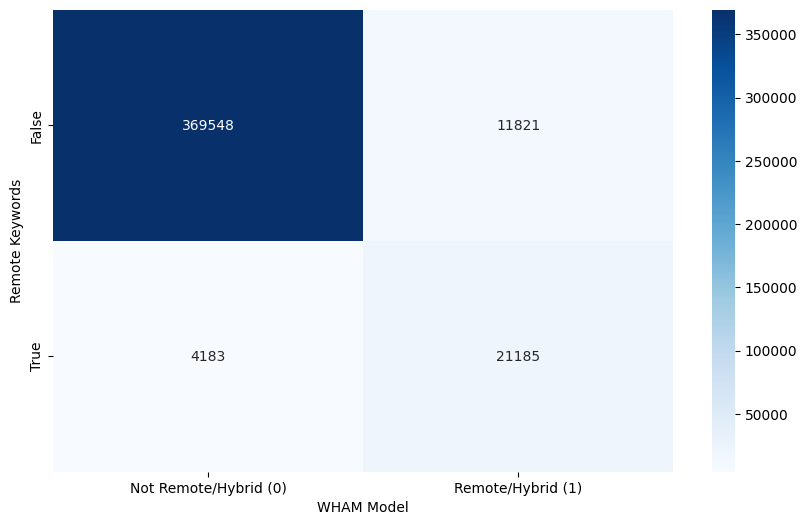

In [67]:


# Pivot the data to create a confusion matrix format
# cf_df = usdf[usdf['REMOTE_TYPE_NAME']!='[None]']
confusion_matrix = wham_df.groupby(['REMOTE_KW', 'wfh_wham']).size().unstack().fillna(0)
confusion_matrix.columns = ['Not Remote/Hybrid (0)', 'Remote/Hybrid (1)']
confusion_matrix.index.name = 'Remote_KW'

# Plot the confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues')
plt.ylabel('Remote Keywords')
plt.xlabel('WHAM Model')
plt.show()


In [68]:
# Calculate metrics
y_true = wham_df['REMOTE_KW']
y_pred = wham_df['wfh_wham']
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.96
Precision: 0.64
Recall: 0.84
F1 Score: 0.73


In [46]:
df.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'AI ROLE', 'wfh_wham_prob', 'wfh_wham',
       'YEAR', 'EDU_ASSISTANCE', 'WLB', 'PAID_LEAVE', 'HEALTH_WELLBEING',
       'PARENTAL_LEAVE', 'CULTURE', 'EXPERIENCE_BUCKET', 'SALARY',
       'LOG_SALARY', 'EXPIRED', 'DURATION', 'DURATION_CALC', 'REMOTE_KW_x',
       'REMOTE_KW_y', 'REMOTE_KW'],
      dtype='object')

# Export

In [ ]:
# # check if columns are the same for 'REMOTE_KW_x','REMOTE_KW_y', 'REMOTE_KW'
# df['REMOTE_KW_x'].equals(df['REMOTE_KW'])

In [50]:
# df.drop(columns=['REMOTE_KW_x','REMOTE_KW_y'], inplace=True)

In [70]:
len(df)

9872916

In [71]:
df.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'SALARY', 'EXPIRED', 'DURATION',
       'AI ROLE', 'wfh_wham_prob', 'wfh_wham', 'YEAR', 'EDU_ASSISTANCE',
       'PAID LEAVE', 'WELLBEING', 'HEALTH_WELLBEING', 'PARENTAL_LEAVE',
       'CULTURE', 'REMOTE_KW'],
      dtype='object')

In [53]:
df['REMOTE_KW'].value_counts(dropna=False)

REMOTE_KW
False    10916201
True       665125
Name: count, dtype: int64

In [47]:
# 11581326
len(df)

11581326

In [72]:
df.to_parquet('../data/us_10m_nointernship_2018_2024_benefits.parquet.gzip', index=False)